ANALYSIS:
1. When loading loading and inspecting a raw external dataset, I had very little challenge, other than the expected non-uniformity within the data as there were missing values and a mix of catagorical and quantitative values.
2. I determined which columns required missing value imputation by using the .info function on the dataframe, which showed me the amount of values within each column. The strategy I used was using a simpleImputer with the strategy being constant rather than median because the data I was filling in for was categorical.
3. Column Transformer lets me apply different preprocessing to both numerical and categorical columns at the same time, rather than manually doing it as I had previously in the notebook. Pipeline connects the steps for preprocessing in the proper order without the need to do it manually. These prevent data leakage because preprocessing parameters are learned only from the training data when the pipeline is in order, and don't allow the test data to influence the preprocessing.
4. The most important relationships with the target variable are from failed logins, ip repuatation score, and login attempts. This reveals to me that the the most telling areas of if there is a data breach are if there are many repeated attempts to login, many of these attempts fail, and if the person logging in has a poor ip repuatation score.

In [69]:
import pandas as pd
df = pd.read_csv('cybersecurity_intrusion_data.csv')
df.head()

,session_id,network_packet_size,protocol_type,login_attempts,session_duration,encryption_used,ip_reputation_score,failed_logins,browser_type,unusual_time_access,attack_detected
0,SID_00001,599,TCP,4,492.983263,DES,0.606818,1,Edge,0,1
1,SID_00002,472,TCP,3,1557.996461,DES,0.301569,0,Firefox,0,0
2,SID_00003,629,TCP,3,75.044262,DES,0.739164,2,Chrome,0,1
3,SID_00004,804,UDP,4,601.248835,DES,0.123267,0,Unknown,0,1
4,SID_00005,453,TCP,5,532.540888,AES,0.054874,1,Firefox,0,0


In [70]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9537 entries, 0 to 9536
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   session_id           9537 non-null   object 
 1   network_packet_size  9537 non-null   int64  
 2   protocol_type        9537 non-null   object 
 3   login_attempts       9537 non-null   int64  
 4   session_duration     9537 non-null   float64
 5   encryption_used      7571 non-null   object 
 6   ip_reputation_score  9537 non-null   float64
 7   failed_logins        9537 non-null   int64  
 8   browser_type         9537 non-null   object 
 9   unusual_time_access  9537 non-null   int64  
 10  attack_detected      9537 non-null   int64  
dtypes: float64(2), int64(5), object(4)
memory usage: 819.7+ KB


In [71]:
df.describe()

,network_packet_size,login_attempts,session_duration,ip_reputation_score,failed_logins,unusual_time_access,attack_detected
count,9537.000000,9537.000000,9537.000000,9537.000000,9537.000000,9537.000000,9537.000000
mean,500.430639,4.032086,792.745312,0.331338,1.517773,0.149942,0.447101
std,198.379364,1.963012,786.560144,0.177175,1.033988,0.357034,0.497220
min,64.000000,1.000000,0.500000,0.002497,0.000000,0.000000,0.000000
25%,365.000000,3.000000,231.953006,0.191946,1.000000,0.000000,0.000000
50%,499.000000,4.000000,556.277457,0.314778,1.000000,0.000000,0.000000
75%,635.000000,5.000000,1105.380602,0.453388,2.000000,0.000000,1.000000
max,1285.000000,13.000000,7190.392213,0.924299,5.000000,1.000000,1.000000


In [72]:
df = df.drop(columns=['session_id'])
df.head()

,network_packet_size,protocol_type,login_attempts,session_duration,encryption_used,ip_reputation_score,failed_logins,browser_type,unusual_time_access,attack_detected
0,599,TCP,4,492.983263,DES,0.606818,1,Edge,0,1
1,472,TCP,3,1557.996461,DES,0.301569,0,Firefox,0,0
2,629,TCP,3,75.044262,DES,0.739164,2,Chrome,0,1
3,804,UDP,4,601.248835,DES,0.123267,0,Unknown,0,1
4,453,TCP,5,532.540888,AES,0.054874,1,Firefox,0,0


In [73]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='most_frequent')
df = df.drop("protocol_type", errors='ignore')
imputer.fit(df)
X = imputer.transform(df)
df_tr = pd.DataFrame(X, columns=df.columns,index=df.index)
df_tr.head()
df_tr.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9537 entries, 0 to 9536
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   network_packet_size  9537 non-null   object
 1   protocol_type        9537 non-null   object
 2   login_attempts       9537 non-null   object
 3   session_duration     9537 non-null   object
 4   encryption_used      9537 non-null   object
 5   ip_reputation_score  9537 non-null   object
 6   failed_logins        9537 non-null   object
 7   browser_type         9537 non-null   object
 8   unusual_time_access  9537 non-null   object
 9   attack_detected      9537 non-null   object
dtypes: object(10)
memory usage: 745.2+ KB


In [74]:
df_num = df_tr.drop(columns=['protocol_type','encryption_used','browser_type'])
df_cat = df_tr[['protocol_type','encryption_used','browser_type']]
#df_cat.head()
df_num.head()

,network_packet_size,login_attempts,session_duration,ip_reputation_score,failed_logins,unusual_time_access,attack_detected
0,599,4,492.983263,0.606818,1,0,1
1,472,3,1557.996461,0.301569,0,0,0
2,629,3,75.044262,0.739164,2,0,1
3,804,4,601.248835,0.123267,0,0,1
4,453,5,532.540888,0.054874,1,0,0


In [75]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
num_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy="median")),
        ('std_scaler', StandardScaler()),
    ])
df_num_tr = num_pipeline.fit_transform(df_num)

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

In [78]:
import pandas as pd

corr_df_num_tr = pd.DataFrame(df_num_tr, columns=df_num.columns)
corr_matrix = corr_df_num_tr.corr()
corr_matrix['attack_detected'].sort_values(ascending=False)

,attack_detected
attack_detected,1.000000
failed_logins,0.363726
login_attempts,0.277320
ip_reputation_score,0.211540
session_duration,0.041602
unusual_time_access,0.008652
network_packet_size,-0.006798


<Axes: >

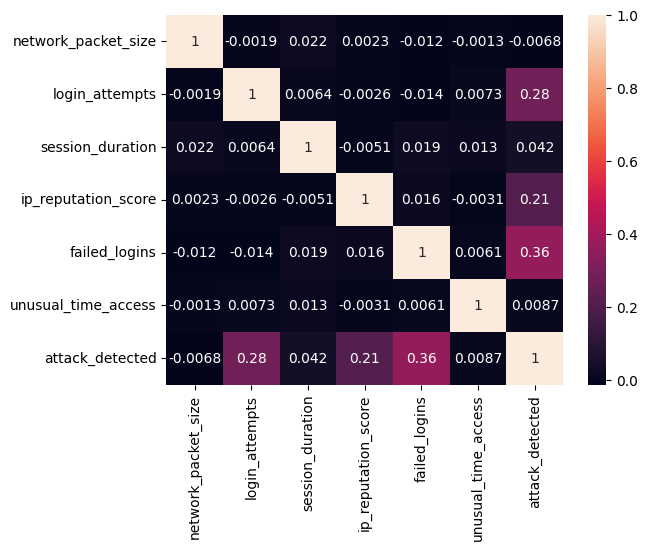

In [82]:
import seaborn
import matplotlib.pyplot as plt
seaborn.heatmap(corr_matrix, annot=True)
#

<Axes: xlabel='network_packet_size', ylabel='Count'>

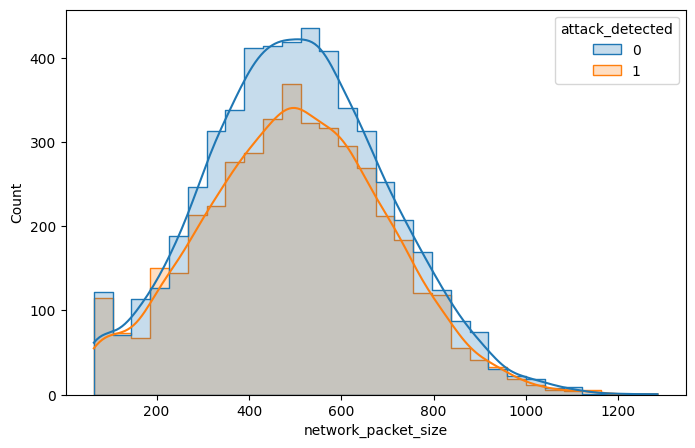

In [87]:
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(data = df_tr, x = 'network_packet_size',hue = 'attack_detected',kde=True,bins=30,element='step')

<Axes: xlabel='session_duration', ylabel='Count'>

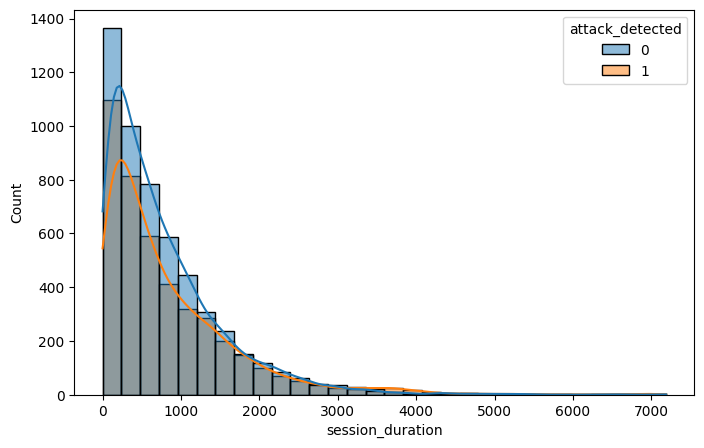

In [90]:
plt.figure(figsize=(8,5))
sns.histplot(data = df_tr, x = 'session_duration',hue = 'attack_detected',kde=True,bins=30)

<Axes: xlabel='network_packet_size', ylabel='session_duration'>

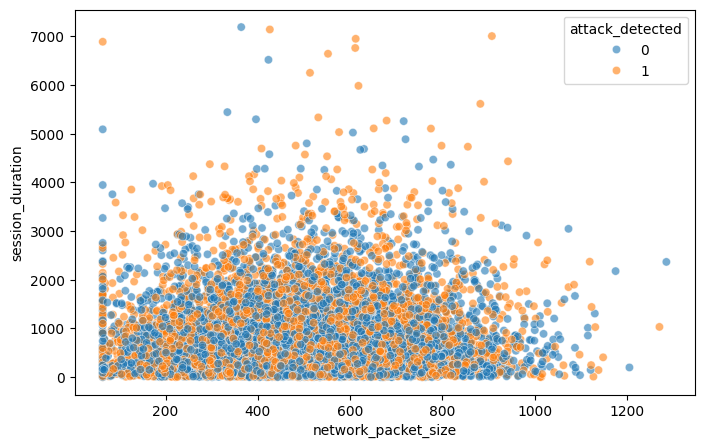

In [92]:
plt.figure(figsize=(8,5))
sns.scatterplot(data = df_tr, x = 'network_packet_size', y = 'session_duration', hue = 'attack_detected',alpha=0.6)
#